<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_CD_EX_31_SP_Prices_Regression_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Avaliativa 3.1 - ECM514 Ciência de Dados**

## Solução

> Os códigos fornecem a solução para quaisquer das versões do exercício. Adapte para os dados do seu exercício específico.

In [ ]:
#@markdown Nome **COMPLETO** e RA

Nome = 'Anna Karenina' #@param {type:"string"}
RA = '22.01164-0' #@param {type:"string"}
#@markdown

suffix_file = RA.replace('.','')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

path = 'https://github.com/Rogerio-mack/work/raw/main/data/'

#@markdown Salve o seu notebook com **IMT_CD_EX_31_\<seu_nome\>.ipynb**

#@markdown Execute esta célula para prosseguir.

In [ ]:
import pandas as pd

df = pd.read_csv('https://github.com/juliaronquetti/Modelo_predicao_SP/raw/refs/heads/main/imoveis_clean.csv')

# df = df.sample(frac=.15, random_state=42).reset_index(drop=True)
df.head()

,title,price,location,date,destaque,categoria,tipo,condominio,area_util,quartos,...,armarios_na_cozinha,armarios_no_quarto,churrasqueira,mobiliado,quarto_de_servico,ar_condicionado,porteiro_24h,varanda,bairro,img_index
0,Apartamento MOBILIADO com ÓTIMA Localização Ág...,350000,"São Paulo, Água Branca",25/04/2024,True,Apartamentos,Padrão,380,43,2,...,1,1,1,1,0,0,0,0,Água Branca,1
1,"Apartamento 115.000,00",115000,"São Paulo, Parque Nações Unidas",24/04/2024,True,Apartamentos,Padrão,150,50,2,...,1,0,0,0,0,0,0,0,Parque Nações Unidas,2
2,Casa de condomínio sobrado para venda com 97 m...,570000,"São Paulo, Jardim Sarah",25/04/2024,False,Casas,Casa de condomínio,320,97,3,...,1,1,0,0,0,1,1,0,Jardim Sarah,4
3,"Cobertura com 3 dormitórios (1 suíte) á venda,...",2250000,"São Paulo, Alto da Lapa",25/04/2024,False,Apartamentos,Cobertura,1790,163,3,...,0,0,1,0,0,0,0,1,Alto da Lapa,5
4,CASA TERREA NO JARDIM BONFIGLIOLI COM 3 DORMI...,820000,"São Paulo, Jardim Bonfiglioli",25/04/2024,False,Casas,Padrão,0,167,3,...,0,0,0,0,0,0,0,0,Jardim Bonfiglioli,8


In [ ]:
df.drop(columns=['location','detalhes_do_imovel','detalhes_do_condominio','bairro','img_index'], inplace=True)
df.head()

,title,price,date,destaque,categoria,tipo,condominio,area_util,quartos,banheiros,...,area_murada,area_de_servico,armarios_na_cozinha,armarios_no_quarto,churrasqueira,mobiliado,quarto_de_servico,ar_condicionado,porteiro_24h,varanda
0,Apartamento MOBILIADO com ÓTIMA Localização Ág...,350000,25/04/2024,True,Apartamentos,Padrão,380,43,2,1,...,0,1,1,1,1,1,0,0,0,0
1,"Apartamento 115.000,00",115000,24/04/2024,True,Apartamentos,Padrão,150,50,2,1,...,0,1,1,0,0,0,0,0,0,0
2,Casa de condomínio sobrado para venda com 97 m...,570000,25/04/2024,False,Casas,Casa de condomínio,320,97,3,3,...,0,1,1,1,0,0,0,1,1,0
3,"Cobertura com 3 dormitórios (1 suíte) á venda,...",2250000,25/04/2024,False,Apartamentos,Cobertura,1790,163,3,4,...,0,1,0,0,1,0,0,0,0,1
4,CASA TERREA NO JARDIM BONFIGLIOLI COM 3 DORMI...,820000,25/04/2024,False,Casas,Padrão,0,167,3,3,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
for c in df.columns[ list(df.columns).index('academia'):: ]:
  df[c] = df[c].astype(bool)

df.dtypes

,0
title,object
price,int64
date,object
destaque,bool
categoria,object
tipo,object
condominio,int64
area_util,int64
quartos,int64
banheiros,int64


In [ ]:
df.drop(columns='piscina', inplace=True)

In [ ]:
df.to_csv('dados_imoveis_SP_OLX_2.csv', index=False)
df.head()

,title,price,date,destaque,categoria,tipo,condominio,area_util,quartos,banheiros,...,area_murada,area_de_servico,armarios_na_cozinha,armarios_no_quarto,churrasqueira,mobiliado,quarto_de_servico,ar_condicionado,porteiro_24h,varanda
0,Apartamento MOBILIADO com ÓTIMA Localização Ág...,350000,25/04/2024,True,Apartamentos,Padrão,380,43,2,1,...,False,True,True,True,True,True,False,False,False,False
1,"Apartamento 115.000,00",115000,24/04/2024,True,Apartamentos,Padrão,150,50,2,1,...,False,True,True,False,False,False,False,False,False,False
2,Casa de condomínio sobrado para venda com 97 m...,570000,25/04/2024,False,Casas,Casa de condomínio,320,97,3,3,...,False,True,True,True,False,False,False,True,True,False
3,"Cobertura com 3 dormitórios (1 suíte) á venda,...",2250000,25/04/2024,False,Apartamentos,Cobertura,1790,163,3,4,...,False,True,False,False,True,False,False,False,False,True
4,CASA TERREA NO JARDIM BONFIGLIOLI COM 3 DORMI...,820000,25/04/2024,False,Casas,Padrão,0,167,3,3,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df = df.drop(columns=['title','date'])


In [ ]:
df.shape

(19151, 29)

In [ ]:
df = pd.concat( [ df.select_dtypes(include='number'), df.select_dtypes(include='object'), df.select_dtypes(include='bool') ],axis=1)
df.shape

(19151, 29)

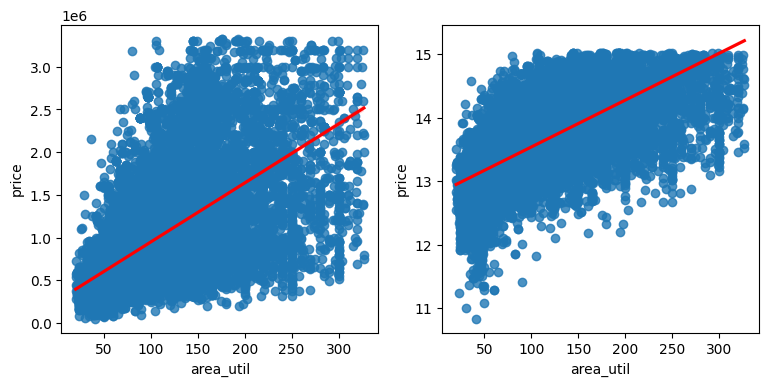

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
sns.regplot(x=df.area_util,y=df.price,line_kws=dict(color="r"))
plt.xlabel('area_util')
plt.ylabel('price')

plt.subplot(1,2,2)
sns.regplot(x=df.area_util,y=np.log(df.price),line_kws=dict(color="r"))
plt.xlabel('area_util')
plt.ylabel('price')
plt.show()

plt.tight_layout()
plt.show()

In [ ]:
df['log_price'] = np.log(df['price'])
df.drop(columns=['price'], inplace=True)
df.head()

,condominio,area_util,quartos,banheiros,vagas_na_garagem,iptu,categoria,tipo,zona,destaque,...,area_de_servico,armarios_na_cozinha,armarios_no_quarto,churrasqueira,mobiliado,quarto_de_servico,ar_condicionado,porteiro_24h,varanda,log_price
0,380,43,2,1,0,0,Apartamentos,Padrão,OESTE,True,...,True,True,True,True,True,False,False,False,False,12.765688
1,150,50,2,1,1,0,Apartamentos,Padrão,OESTE,True,...,True,True,False,False,False,False,False,False,False,11.652687
2,320,97,3,3,2,19,Casas,Casa de condomínio,OESTE,False,...,True,True,True,False,False,False,True,True,False,13.253392
3,1790,163,3,4,3,616,Apartamentos,Cobertura,OESTE,False,...,True,False,False,True,False,False,False,False,True,14.626441
4,0,167,3,3,4,0,Casas,Padrão,OESTE,False,...,False,False,False,False,False,False,False,False,False,13.617060


In [ ]:
from sklearn.preprocessing import StandardScaler

col_numbers = df.select_dtypes(include='number').columns

scaler = StandardScaler()
df[col_numbers] = scaler.fit_transform(df[col_numbers])

df.head()

,condominio,area_util,quartos,banheiros,vagas_na_garagem,iptu,categoria,tipo,zona,destaque,...,area_de_servico,armarios_na_cozinha,armarios_no_quarto,churrasqueira,mobiliado,quarto_de_servico,ar_condicionado,porteiro_24h,varanda,log_price
0,-0.578635,-1.061793,-0.560800,-1.066331,-1.446905,-0.790937,Apartamentos,Padrão,OESTE,True,...,True,True,True,True,True,False,False,False,False,-1.204809
1,-0.861417,-0.946835,-0.560800,-1.066331,-0.506542,-0.790937,Apartamentos,Padrão,OESTE,True,...,True,True,False,False,False,False,False,False,False,-2.824199
2,-0.652404,-0.174971,0.622527,0.648016,0.433821,-0.729392,Casas,Casa de condomínio,OESTE,False,...,True,True,True,False,False,False,True,True,False,-0.495213
3,1.154936,0.908923,0.622527,1.505190,1.374184,1.204413,Apartamentos,Cobertura,OESTE,False,...,True,False,False,True,False,False,False,False,True,1.502541
4,-1.045839,0.974613,0.622527,0.648016,2.314546,-0.790937,Casas,Padrão,OESTE,False,...,False,False,False,False,False,False,False,False,False,0.033915


In [ ]:
import statsmodels.formula.api as sm

target = 'log_price'
formula = f'{target} ~ {" + ".join(df.drop(columns=[target]))}'
display(formula)

lm = sm.ols(formula=formula, data=df).fit()
print(lm.summary())


'log_price ~ condominio + area_util + quartos + banheiros + vagas_na_garagem + iptu + categoria + tipo + zona + destaque + academia + elevador + permitido_animais + portaria + salao_de_festas + condominio_fechado + seguranca_24h + portao_eletronico + area_murada + area_de_servico + armarios_na_cozinha + armarios_no_quarto + churrasqueira + mobiliado + quarto_de_servico + ar_condicionado + porteiro_24h + varanda'

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     1318.
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:19:08   Log-Likelihood:                -15224.
No. Observations:               19151   AIC:                         3.052e+04
Df Residuals:                   19114   BIC:                         3.081e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [ ]:
pvalues = pd.DataFrame(lm.pvalues)
pvalues.columns = ['pvalues']
pvalues['significativo'] = pvalues['pvalues'] < 0.05
pvalues = pvalues.sort_values(by='pvalues', ascending=False)
pvalues[~pvalues.significativo].index

Index(['tipo[T.Padrão]', 'armarios_na_cozinha[T.True]', 'tipo[T.Cobertura]',
       'quarto_de_servico[T.True]', 'area_murada[T.True]', 'tipo[T.Loft]',
       'tipo[T.Duplex ou triplex]', 'armarios_no_quarto[T.True]',
       'portao_eletronico[T.True]', 'tipo[T.Casa de vila]',
       'porteiro_24h[T.True]', 'academia[T.True]', 'portaria[T.True]'],
      dtype='object')

In [ ]:
df.drop(columns=['tipo','quarto_de_servico','area_murada','armarios_na_cozinha','portaria','mobiliado','armarios_no_quarto',
       'portao_eletronico','porteiro_24h'], inplace=True)

In [ ]:
import statsmodels.formula.api as sm

target = 'log_price'
formula = f'{target} ~ {" + ".join(df.drop(columns=[target]))}'
display(formula)

lm = sm.ols(formula=formula, data=df).fit()
print(lm.summary())

'log_price ~ condominio + area_util + quartos + banheiros + vagas_na_garagem + iptu + categoria + zona + destaque + academia + elevador + permitido_animais + salao_de_festas + condominio_fechado + seguranca_24h + area_de_servico + churrasqueira + ar_condicionado + varanda'

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     2145.
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:19:13   Log-Likelihood:                -15269.
No. Observations:               19151   AIC:                         3.058e+04
Df Residuals:                   19128   BIC:                         3.077e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
# df['area_util_garagem'] = df['area_util']*df['vagas_na_garagem']
df['area_util_quartos'] = df['area_util']*df['quartos']
df['area_util_banheiros'] = df['area_util']*df['banheiros']

In [ ]:
import statsmodels.formula.api as sm

# df.drop(columns=['varanda'], inplace=True) #
df.drop(columns=['academia'], inplace=True)

target = 'log_price'
formula = f'{target} ~ {" + ".join(df.drop(columns=[target]))}'
display(formula)

lm = sm.ols(formula=formula, data=df).fit()
print(lm.summary())

'log_price ~ condominio + area_util + quartos + banheiros + vagas_na_garagem + iptu + categoria + zona + destaque + elevador + permitido_animais + salao_de_festas + condominio_fechado + seguranca_24h + area_de_servico + churrasqueira + ar_condicionado + varanda + area_util_quartos + area_util_banheiros'

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     2386.
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:20:07   Log-Likelihood:                -14217.
No. Observations:               19151   AIC:                         2.848e+04
Df Residuals:                   19127   BIC:                         2.867e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     357.5
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:33:08   Log-Likelihood:                -2223.2
No. Observations:                2873   AIC:                             4490.
Df Residuals:                    2851   BIC:                             4622.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
coef = pd.DataFrame(lm.params)
coef.columns = ['coef']
coef['abs_coef'] = np.abs(coef['coef'])
coef = coef.sort_values(by='abs_coef', ascending=False)
coef

,coef,abs_coef
zona[T.NORTE],-0.456499,0.456499
zona[T.LESTE],-0.381770,0.381770
area_util,0.361278,0.361278
destaque[T.True],-0.215351,0.215351
ar_condicionado[T.True],0.207989,0.207989
salao_de_festas[T.True],0.202233,0.202233
banheiros,0.186297,0.186297
condominio,0.168055,0.168055
categoria[T.Casas],-0.160963,0.160963
elevador[T.True],-0.135103,0.135103


In [ ]:
len(coef)

22

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = df.select_dtypes(include='object').columns
encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
df = df.drop(columns=categorical_cols)

df = pd.concat([df, encoded_df], axis=1)
df.head()

,condominio,area_util,quartos,banheiros,vagas_na_garagem,iptu,destaque,elevador,permitido_animais,salao_de_festas,...,area_de_servico,churrasqueira,ar_condicionado,varanda,log_price,categoria_Casas,zona_LESTE,zona_NORTE,zona_OESTE,zona_SUL
0,0.182703,-0.626899,-0.531782,-0.186593,-0.485690,-0.759731,False,False,False,True,...,False,True,False,False,1.185335,0.0,0.0,0.0,1.0,0.0
1,0.693698,0.754197,0.659029,0.668400,0.457777,-0.750138,False,False,False,True,...,True,True,False,False,1.906665,0.0,0.0,0.0,0.0,1.0
2,-0.060628,-0.610457,-0.531782,-1.041585,-0.485690,-0.312058,False,True,True,True,...,False,True,False,False,-1.171637,0.0,0.0,1.0,0.0,0.0
3,1.216859,0.951497,0.659029,1.523393,-0.485690,-0.791708,False,False,False,False,...,False,False,False,False,0.453553,0.0,0.0,0.0,0.0,0.0
4,-1.033952,0.869289,0.659029,-0.186593,0.457777,-0.104210,False,False,False,False,...,False,False,False,False,-0.422254,1.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor

X = df.drop(columns='log_price')
y = df['log_price']

In [ ]:
len(X.iloc[0])

21

In [ ]:


models = {}
for regression_model in [LinearRegression(),
                         Ridge(alpha=1.0),
                         Lasso(alpha=0.1),
                         HuberRegressor(),
                         # RANSACRegressor(random_state=42),
                         TheilSenRegressor(random_state=42),
                         ElasticNet(alpha=0.5)]:
  models[regression_model] = {}

  result = regression_model.fit(X, y)
  print(f'Model {regression_model} score = {result.score(X, y):.4f}')

  models[regression_model]['score'] = result.score(X, y)
  models[regression_model]['coef'] = result.coef_
  models[regression_model]['intercept'] = result.intercept_
  models[regression_model]['model'] = result

Model LinearRegression() score = 0.7248
Model Ridge() score = 0.7248
Model Lasso(alpha=0.1) score = 0.6258
Model HuberRegressor() score = 0.7240
Model TheilSenRegressor(random_state=42) score = 0.7182
Model ElasticNet(alpha=0.5) score = 0.4997


In [ ]:
model_results = pd.DataFrame(models).T.sort_values(by='score', ascending=False)
model_results

,score,coef,intercept,model
LinearRegression(),0.724794,"[0.16805469161304176, 0.3612775316707606, 0.06...",0.055304,LinearRegression()
Ridge(),0.724793,"[0.16850232031625356, 0.361034883721478, 0.067...",0.054306,Ridge()
HuberRegressor(),0.723984,"[0.17597678562636113, 0.35132354251401027, 0.0...",0.058741,HuberRegressor()
TheilSenRegressor(random_state=42),0.71819,"[0.21567754136228343, 0.3890264255615465, 0.04...",0.06489,TheilSenRegressor(random_state=42)
Lasso(alpha=0.1),0.625831,"[0.2981511696375821, 0.30051789374784327, 0.0,...",-0.0,Lasso(alpha=0.1)
ElasticNet(alpha=0.5),0.4997,"[0.164469485149821, 0.19857390230198227, 0.001...",-0.0,ElasticNet(alpha=0.5)


In [ ]:
model_results.coef.apply(lambda x: pd.Series(x)).head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
LinearRegression(),0.168055,0.361278,0.067503,0.186297,0.112138,0.039059,-0.215351,-0.135103,-0.077020,0.202233,...,-0.021737,0.072696,0.068170,0.207989,0.094080,-0.160963,-0.381770,-0.456499,0.100758,0.099942
Ridge(),0.168502,0.361035,0.067443,0.186354,0.112036,0.039179,-0.205169,-0.134740,-0.076938,0.202090,...,-0.022179,0.072395,0.068120,0.207345,0.093832,-0.160266,-0.379919,-0.454657,0.101638,0.100598
HuberRegressor(),0.175977,0.351324,0.077785,0.182579,0.127808,0.032762,-0.150532,-0.137445,-0.080656,0.194916,...,0.003461,0.077288,0.071601,0.245503,0.115022,-0.132594,-0.388549,-0.473051,0.078979,0.090557
TheilSenRegressor(random_state=42),0.215678,0.389026,0.047820,0.169802,0.144591,0.055166,-0.016674,-0.160035,-0.081604,0.198935,...,-0.002213,0.064819,0.111345,0.161045,0.065746,-0.090597,-0.395014,-0.435381,0.076912,0.083233
Lasso(alpha=0.1),0.298151,0.300518,0.000000,0.203421,0.067156,0.000851,-0.000000,-0.000000,-0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000


In [ ]:
len(model_results.coef.iloc[0])

21

In [ ]:
result1 = model_results.iloc[0]['model']
result2 = model_results.iloc[1]['model']

In [ ]:
#
# melhor modelo statsmodels
#
models = {}
models['top_statsmodels'] = lm # seu modelo

#
# melhores modelos scikit-learn, Top1 e Top2
#
models['top1_scikit_learn'] = {}
models['top1_scikit_learn']['score'] = result1.score(X, y)
models['top1_scikit_learn']['coef'] = result1.coef_
models['top1_scikit_learn']['intercept'] = result1.intercept_
models['top1_scikit_learn']['model'] = result1

models['top2_scikit_learn'] = {}
models['top2_scikit_learn']['score'] = result2.score(X, y)
models['top2_scikit_learn']['coef'] = result2.coef_
models['top2_scikit_learn']['intercept'] = result2.intercept_
models['top2_scikit_learn']['model'] = result2

In [ ]:
#@markdown Execute para gerar seu arquivo de respostas
import pickle
import numpy as np
import pandas as pd

# Define the filename with .pkl extension
filename = 'Ex_31_' + Nome.replace(' ','_') + '_' + RA.replace('.','') + '.pkl'

# Serialize the dictionary to a pickle file
with open(filename, 'wb') as f:
      pickle.dump(models, f)

from IPython.display import display, HTML

# display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
display(HTML('<span style="font-size: 24px; color: blue;">Respostas</span>'))
print()
print(models['top_statsmodels'].summary())
print()
display(pd.DataFrame([models['top1_scikit_learn'],models['top2_scikit_learn']]))


print()
display(HTML('<span style="font-size: 14px; color: blue;">Respostas salvas com sucesso em:</span>'))
print()
fname = f'<span style="font-size: 14px; color: blue;"><strong>{filename}</strong></span>'
display(HTML(fname))


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     357.5
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:33:13   Log-Likelihood:                -2223.2
No. Observations:                2873   AIC:                             4490.
Df Residuals:                    2851   BIC:                             4622.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept          

,score,coef,intercept,model
0,0.724794,"[0.16805469161304176, 0.3612775316707606, 0.06...",0.055304,LinearRegression()
1,0.724793,"[0.16850232031625356, 0.361034883721478, 0.067...",0.054306,Ridge()
